In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import optax

import dismech_jax as djx


class Slinky1D(djx.System):
    """Simple 2-node 1D spring under exact displacement control."""

    l_k: jax.Array
    x_left: jax.Array

    def get_q(self, disp: jax.Array, q0: jax.Array) -> jax.Array:
        """
        disp is the exact prescribed displacement value for the pulled node.

        Left node is fixed at x_left.
        Right node is prescribed directly to disp.
        """
        q = q0.at[0].set(self.x_left)
        q = q.at[1].set(disp)
        return q

    def get_E(
        self, disp: jax.Array, q: jax.Array, model: eqx.Module, aux: None
    ) -> jax.Array:
        eps = (q[1] - q[0]) / self.l_k - 1.0
        return model(jnp.array([eps]))

    def get_F(
        self, disp: jax.Array, q: jax.Array, model: eqx.Module, aux: None
    ) -> jax.Array:
        # No free DOFs in this 2-node fully prescribed toy problem.
        return jnp.zeros_like(q)

    def get_H(
        self, disp: jax.Array, q: jax.Array, model: eqx.Module, aux: None
    ) -> jax.Array:
        # Dummy Hessian for API compatibility.
        return jnp.eye(q.shape[0])

    def get_reaction_force(
        self, disp: jax.Array, q: jax.Array, model: eqx.Module, aux: None
    ) -> jax.Array:
        """
        Reaction force at the pulled (right) node.

        If your measured force has opposite sign convention,
        flip the sign here.
        """
        dEdq = jax.grad(self.get_E, argnums=1)(disp, q, model, aux)
        return dEdq[1]


class SlinkyNN(eqx.Module):
    w1: jax.Array
    b1: jax.Array
    w2: jax.Array
    b2: jax.Array
    k0_raw: jax.Array

    def __init__(self, key, K_initial=1.0):
        hidden_size = 10
        k1, k2 = jax.random.split(key)
        self.w1 = jax.random.normal(k1, (hidden_size, 1)) * 0.01
        self.b1 = jnp.zeros((hidden_size,))
        self.w2 = jax.random.normal(k2, (1, hidden_size)) * 0.01
        self.b2 = jnp.zeros((1,))
        self.k0_raw = jnp.array(K_initial)

    def get_K(self, eps):
        h = jax.nn.softplus(self.w1 @ eps + self.b1)
        delta_raw = (self.w2 @ h + self.b2).squeeze()   # signed correction
        return jax.nn.softplus(self.k0_raw + delta_raw)

    def __call__(self, eps):
        eps_scalar = eps.squeeze()
        return self.get_K(eps) * eps_scalar**2


# =========================================================
# Load data from saved format with exact displacements
# =========================================================
data = np.load("slinky_pulling_force_data_exact.npz")

force_truth = jnp.array(data["F"])         # shape (N,)
disps = jnp.array(data["disps"])           # exact pulled-node positions
initial_last_node_x = float(data["initial_last_node_x"])
final_last_node_x = float(data["final_last_node_x"])

num_steps = force_truth.shape[0]

# Two-node rod:
# node 0 fixed at x = 0
# node 1 starts at initial_last_node_x
x_left = 0.0
q0 = jnp.array([x_left, initial_last_node_x])

# Initial rest length
l_k0 = q0[1] - q0[0]

slinky = Slinky1D(
    l_k=jnp.array(l_k0),
    x_left=jnp.array(x_left),
)

model = SlinkyNN(jax.random.PRNGKey(42), K_initial=1.0)
# model = SlinkyNN(jax.random.PRNGKey(42))


# =========================================================
# Train/test split
# Use displacement directly instead of lambda
# =========================================================
disp_min = disps.min()
disp_max = disps.max()

test_range = (
    disp_min + 0.2 * (disp_max - disp_min),
    disp_min + 0.8 * (disp_max - disp_min),
)

train_mask = (disps <= test_range[0]) | (disps >= test_range[1])
test_mask = (disps > test_range[0]) & (disps < test_range[1])

train_disps = disps[train_mask]
train_force_truth = force_truth[train_mask]

test_disps = disps[test_mask]
test_force_truth = force_truth[test_mask]

print("Num total samples:", num_steps)
print("Num train samples:", train_disps.shape[0])
print("Num test samples :", test_disps.shape[0])
print("Initial pulled-node x:", initial_last_node_x)
print("Final pulled-node x  :", final_last_node_x)
print("Rest length l_k0     :", l_k0)


# =========================================================
# Prediction: exact displacement -> prescribed q -> reaction force
# =========================================================
def predict_force(model, disp_vals):
    def one_force(disp):
        q = slinky.get_q(disp, q0)
        return slinky.get_reaction_force(disp, q, model, None)

    return jax.vmap(one_force)(disp_vals)


# =========================================================
# Loss
# =========================================================
def train_loss(model):
    pred_force = predict_force(model, train_disps)
    return jnp.mean((train_force_truth - pred_force) ** 2)


lr = 1e-1
schedule = optax.piecewise_constant_schedule(
    init_value=lr,
    boundaries_and_scales={7500: 0.1},
)
optimizer = optax.adam(learning_rate=schedule)

opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))


@eqx.filter_jit
def train_step(carry, _):
    model, opt_state = carry
    loss_val, grads = eqx.filter_value_and_grad(train_loss)(model)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return (model, opt_state), loss_val


num_epochs = 10000
log_freq = 500


def train_loop(model, opt_state):
    def scan_fn(carry, i):
        next_carry, loss_val = train_step(carry, None)

        def log_loss(_):
            jax.debug.print("Epoch: {x}, Train Loss: {y}", x=i, y=loss_val)

        jax.lax.cond(i % log_freq == 0, log_loss, lambda _: None, operand=None)
        return next_carry, loss_val

    (final_model, final_opt_state), loss_history = jax.lax.scan(
        scan_fn, (model, opt_state), jnp.arange(num_epochs + 1)
    )
    return final_model, loss_history


final_model, history = train_loop(model, opt_state)


# =========================================================
# Evaluate on full displacement trajectory
# =========================================================
pred_full_force = predict_force(final_model, disps)

train_mse = jnp.mean((force_truth[train_mask] - pred_full_force[train_mask]) ** 2)
test_mse = jnp.mean((force_truth[test_mask] - pred_full_force[test_mask]) ** 2)

print("Final train force MSE:", train_mse)
print("Final test  force MSE:", test_mse)

Num total samples: 50
Num train samples: 20
Num test samples : 30
Initial pulled-node x: 0.2881684163230799
Final pulled-node x  : 0.4712011868763382
Rest length l_k0     : 0.28816843
Epoch: 0, Train Loss: 10.838900566101074
Epoch: 500, Train Loss: 0.16045892238616943
Epoch: 1000, Train Loss: 0.16045837104320526
Epoch: 1500, Train Loss: 0.16045719385147095
Epoch: 2000, Train Loss: 0.16045302152633667
Epoch: 2500, Train Loss: 0.006085879169404507
Epoch: 3000, Train Loss: 0.0038974967319518328
Epoch: 3500, Train Loss: 0.003882254008203745
Epoch: 4000, Train Loss: 0.0038619437254965305
Epoch: 4500, Train Loss: 0.0038360401522368193
Epoch: 5000, Train Loss: 0.003823046339675784
Epoch: 5500, Train Loss: 0.0038216584362089634
Epoch: 6000, Train Loss: 0.0038212910294532776
Epoch: 6500, Train Loss: 0.00382081582210958
Epoch: 7000, Train Loss: 0.0038201825227588415
Epoch: 7500, Train Loss: 0.0038194835651665926
Epoch: 8000, Train Loss: 0.003819369478151202
Epoch: 8500, Train Loss: 0.00381925445

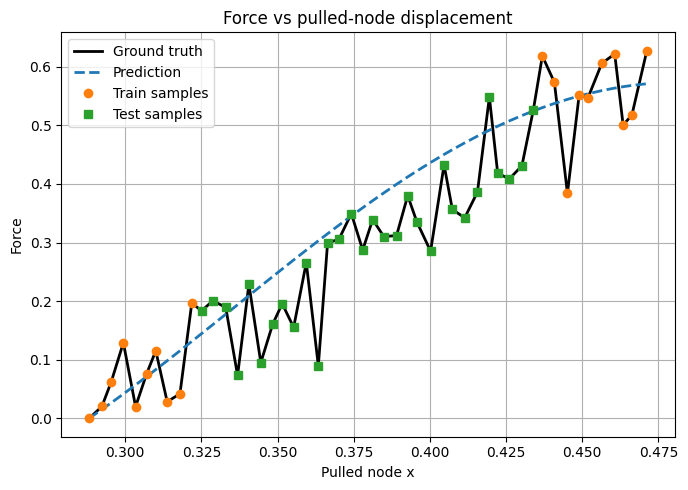

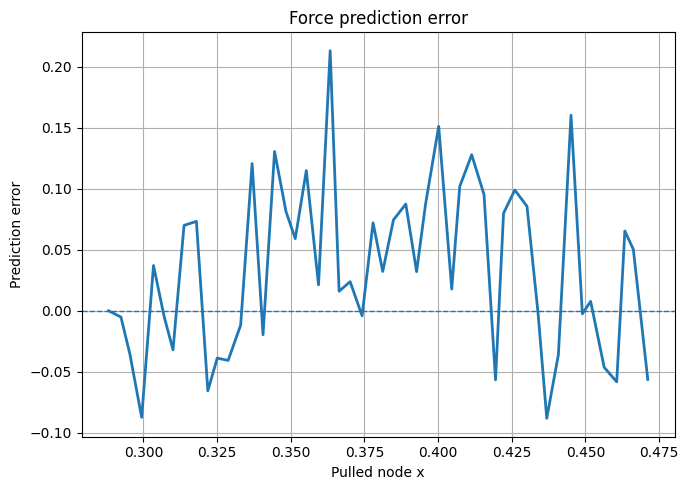

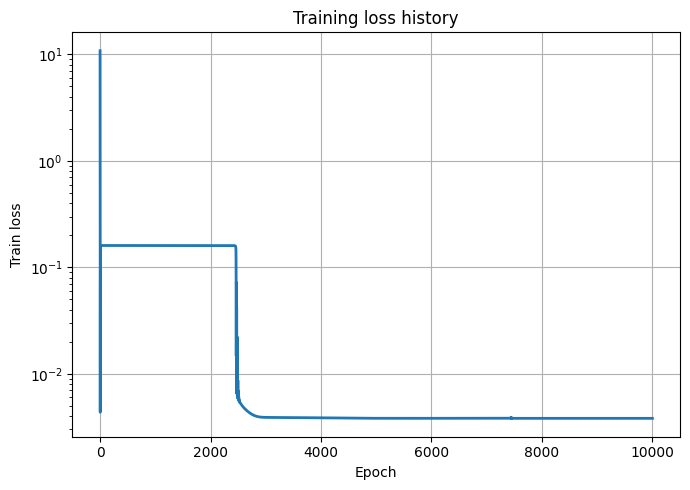

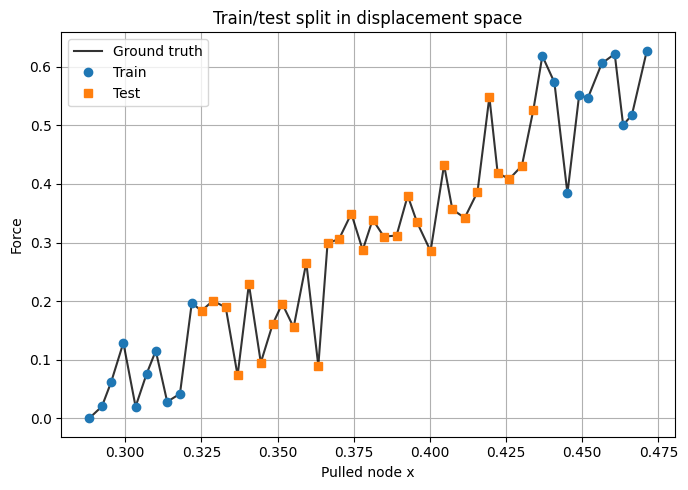

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# convert to numpy for plotting
disps_np = np.array(disps)
force_truth_np = np.array(force_truth)
pred_full_force_np = np.array(pred_full_force)

train_mask_np = np.array(train_mask)
test_mask_np = np.array(test_mask)
history_np = np.array(history)


# =========================================================
# 1. Force vs pulled-node displacement
# =========================================================
plt.figure(figsize=(7, 5))
plt.plot(disps_np, force_truth_np, "k-", linewidth=2, label="Ground truth")
plt.plot(disps_np, pred_full_force_np, "--", linewidth=2, label="Prediction")

plt.plot(
    disps_np[train_mask_np],
    force_truth_np[train_mask_np],
    "o",
    markersize=6,
    label="Train samples",
)
plt.plot(
    disps_np[test_mask_np],
    force_truth_np[test_mask_np],
    "s",
    markersize=6,
    label="Test samples",
)

plt.xlabel("Pulled node x")
plt.ylabel("Force")
plt.title("Force vs pulled-node displacement")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 2. Prediction error vs pulled-node displacement
# =========================================================
error_np = pred_full_force_np - force_truth_np

plt.figure(figsize=(7, 5))
plt.plot(disps_np, error_np, linewidth=2)
plt.axhline(0.0, linestyle="--", linewidth=1)

plt.xlabel("Pulled node x")
plt.ylabel("Prediction error")
plt.title("Force prediction error")
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 3. Training loss history
# =========================================================
plt.figure(figsize=(7, 5))
plt.plot(history_np, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Training loss history")
plt.yscale("log")
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 4. Train/test points only, shown on the same force-displacement curve
# =========================================================
plt.figure(figsize=(7, 5))
plt.plot(disps_np, force_truth_np, "k-", linewidth=1.5, alpha=0.8, label="Ground truth")
plt.plot(disps_np[train_mask_np], force_truth_np[train_mask_np], "o", label="Train")
plt.plot(disps_np[test_mask_np], force_truth_np[test_mask_np], "s", label="Test")

plt.xlabel("Pulled node x")
plt.ylabel("Force")
plt.title("Train/test split in displacement space")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()